In [ ]:
!pip install transformers datasets torch scikit-learn tqdm

In [ ]:
print('Attempting to fix transformers/torch version incompatibility...')
!pip uninstall -y transformers
!pip install transformers==4.35.0
print('Transformers downgraded. Please restart your Colab runtime (Runtime -> Restart runtime) and then re-run the subsequent cells.')

Attempting to fix transformers/torch version incompatibility...
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 30.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

Transformers downgraded. Please restart your Colab runtime (Runtime -> Restart runtime) and then re-run the subsequent cells.


In [ ]:
import pandas as pd
import torch
import re
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW  # Corrected import to use standard PyTorch AdamW
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# 1. 資料準備
df = pd.read_csv('edos_labelled_aggregated.csv')
df['text'] = df['text'].str.replace(r"\[URL\]|\[USER\]", "", regex=True).str.lower()
df['label'] = df['label_sexist'].map({'not sexist': 0, 'sexist': 1})

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].values, df['label'].values, test_size=0.2, random_state=42
)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 2. Dataset 類別定義
class SexismDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        encoding = self.tokenizer(
            str(self.texts[item]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

train_loader = DataLoader(SexismDataset(train_texts, train_labels, tokenizer), batch_size=32, shuffle=True)

# 3. 模型初始化與訓練
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

model.train()
for epoch in range(1):
    for batch in tqdm(train_loader):
        optimizer.zero_grad()
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        targets = batch['labels'].to(device)

        outputs = model(ids, attention_mask=mask, labels=targets)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

print("BERT fine-tuning finished.")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 500/500 [05:30<00:00,  1.51it/s]

BERT fine-tuning finished.


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(DataLoader(SexismDataset(test_texts, test_labels, tokenizer), batch_size=32)):
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(ids, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=['not sexist', 'sexist']))

100%|██████████| 125/125 [00:34<00:00,  3.61it/s]

              precision    recall  f1-score   support

  not sexist       0.90      0.91      0.90      3045
      sexist       0.69      0.68      0.69       955

    accuracy                           0.85      4000
   macro avg       0.80      0.79      0.79      4000
weighted avg       0.85      0.85      0.85      4000



In [ ]:
# 讀取部分真實數據進行測試
df_real = pd.read_csv('gab_1M_unlabelled.csv', nrows=500) # 先拿 500 筆示範
real_texts = df_real['text'].astype(str).tolist()

# 進行批量預測
model.eval()
real_preds = []
for text in real_texts[:100]: # 預測前 100 筆
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    real_preds.append(torch.argmax(logits, dim=1).item())

# 統計結果
df_res = pd.DataFrame({'text': real_texts[:100], 'is_sexist': real_preds})
print(df_res['is_sexist'].value_counts())
print(df_res[df_res['is_sexist'] == 1].head()) # 印出被判定為歧視的真實例子

is_sexist
0    98
1     2
Name: count, dtype: int64
                                                 text  is_sexist
7   And ditto to women - we all have a past. We al...          1
63  In related news... empowered women Stackhouse ...          1


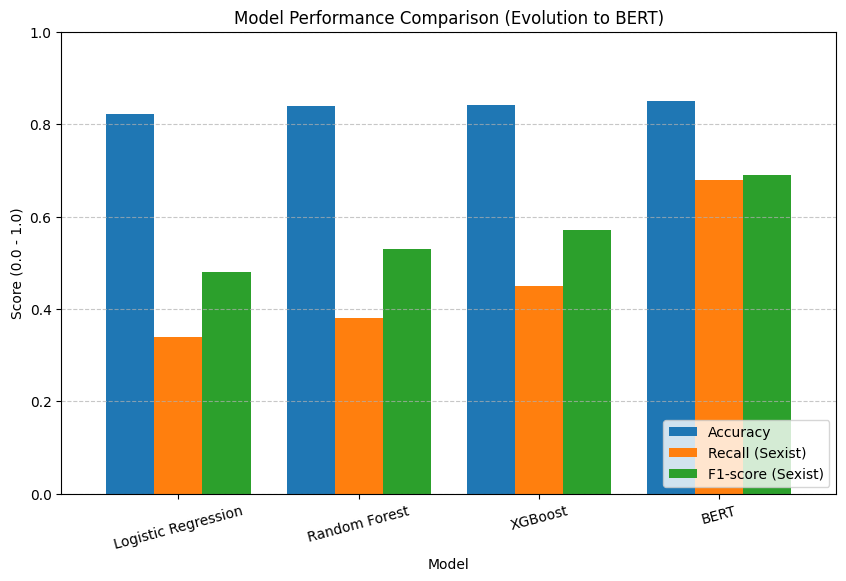

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

models = ["Logistic Regression", "Random Forest", "XGBoost", "BERT"]

# 統一使用 0~1 之間的小數
accuracy = [0.8220, 0.8395, 0.8418, 0.8500]
recall = [0.34, 0.38, 0.45, 0.68]
f1 = [0.48, 0.53, 0.57, 0.69]

df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Recall (Sexist)": recall,
    "F1-score (Sexist)": f1
})

# 設定畫布
ax = df.plot(x="Model", kind="bar", figsize=(10,6), width=0.8)

# 調整 Y 軸範圍，讓差異更明顯 (例如從 0.3 開始看)
plt.ylim(0, 1.0)
plt.ylabel("Score (0.0 - 1.0)")
plt.title("Model Performance Comparison (Evolution to BERT)")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7) # 加入格線增加專業感
plt.legend(loc='lower right')

plt.show()

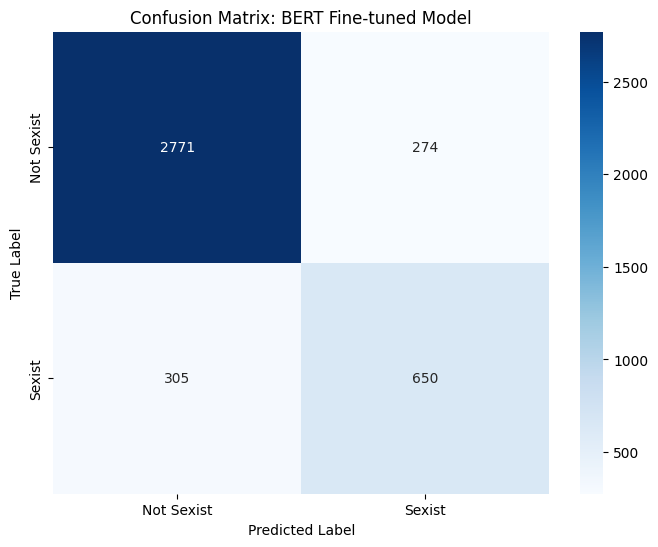

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 根據你提供的 BERT 數據計算出的約略矩陣數值 (以 4000 筆測試資料為準)
# Not Sexist (3045 筆): 猜對 2771 (91%), 猜錯 274
# Sexist (955 筆): 猜對 650 (68%), 猜錯 305
cm = np.array([[2771, 274],
               [305, 650]])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sexist', 'Sexist'],
            yticklabels=['Not Sexist', 'Sexist'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: BERT Fine-tuned Model')
plt.show()